In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Data preparation

In [2]:
data = "https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv"

In [3]:
df = pd.read_csv(data)

In [4]:
len(df)

11914

In [5]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [6]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [7]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [8]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [9]:
df.dtypes[df.dtypes == 'str']

make                 str
model                str
engine_fuel_type     str
transmission_type    str
driven_wheels        str
market_category      str
vehicle_size         str
vehicle_style        str
dtype: object

In [10]:
df.dtypes[df.dtypes == 'str'].index

Index(['make', 'model', 'engine_fuel_type', 'transmission_type',
       'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style'],
      dtype='str')

In [11]:
column = list(df.dtypes[df.dtypes == 'str'].index)

In [12]:
print(column)

['make', 'model', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style']


In [13]:
for col in column :
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [14]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


## EDA

In [15]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:7])
    print(df[col].nunique())
    print('-----------------------------------------------------------')

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler', 'nissan', 'volvo']
Length: 7, dtype: str
48
-----------------------------------------------------------
model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class', '2_series',
 '200']
Length: 7, dtype: str
914
-----------------------------------------------------------
year
[2011 2012 2013 1992 1993 1994 2017]
28
-----------------------------------------------------------
engine_fuel_type
<StringArray>
[                 'premium_unleaded_(required)',
                             'regular_unleaded',
               'premium_unleaded_(recommended)',
                     'flex-fuel_(unleaded/e85)',
                                       'diesel',
                                     'electric',
 'flex-fuel_(premium_unleaded_recommended/e85)']
Length: 7, dtype: str
10
-----------------------------------------------------------
engine_hp
[335. 300. 230. 320. 172. 160. 130.]
356
----------------------

<Axes: xlabel='msrp', ylabel='Count'>

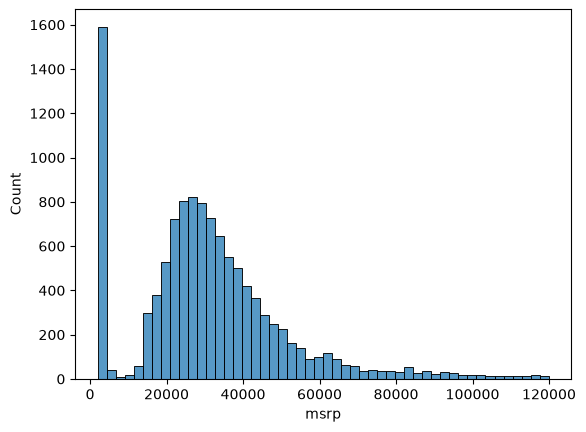

In [16]:
sns.histplot(df.msrp[df.msrp < 120000], bins=50)

In [17]:
price_logs = np.log1p(df.msrp)
print(price_logs)

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64


<Axes: xlabel='msrp', ylabel='Count'>

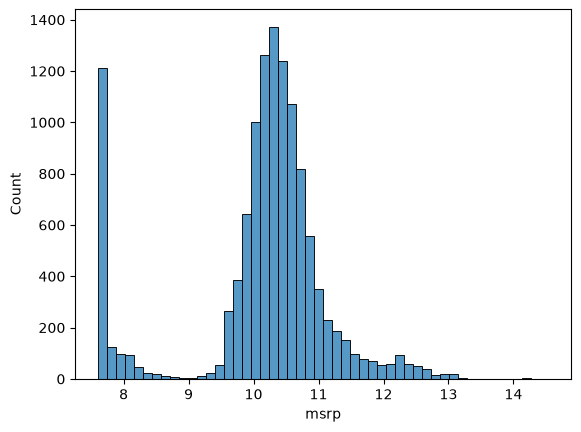

In [18]:
sns.histplot(price_logs, bins=50)

In [19]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## Setting up the validation framework

In [20]:
n = len(df)

In [21]:
print(n)

11914


In [22]:
train_size = int(0.6*n)
val_size = int(0.2*n)
test_size = n - (train_size + val_size)
print(train_size)
print(val_size)
print(test_size)
print(train_size + val_size + test_size)

7148
2382
2384
11914


In [23]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [24]:
np.random.seed(2)
idx = np.arange(n)
np.random.shuffle(idx)

In [25]:
df_train = df.iloc[idx[:train_size]]
df_val = df.iloc[idx[train_size:train_size+val_size]]
df_test = df.iloc[idx[train_size+val_size:]]

In [26]:
len(df_train), len(df_val), len(df_test)

(7148, 2382, 2384)

In [27]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11913,lincoln,zephyr,2006,regular_unleaded,221.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,26,17,61,28995
3602,cadillac,dts,2010,premium_unleaded_(recommended),275.0,8.0,automatic,front_wheel_drive,4.0,luxury,large,sedan,23,15,1624,46280
434,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
1902,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215


In [28]:
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)

In [29]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7143,lincoln,zephyr,2006,regular_unleaded,221.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,26,17,61,28995
7144,cadillac,dts,2010,premium_unleaded_(recommended),275.0,8.0,automatic,front_wheel_drive,4.0,luxury,large,sedan,23,15,1624,46280
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215


In [30]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [31]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

## Linear Regression

In [32]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [33]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [34]:
df_train.dtypes == 'float'

make                 False
model                False
year                 False
engine_fuel_type     False
engine_hp             True
engine_cylinders      True
transmission_type    False
driven_wheels        False
number_of_doors       True
market_category      False
vehicle_size         False
vehicle_style        False
highway_mpg          False
city_mpg             False
popularity           False
dtype: bool

In [35]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg',
        'city_mpg', 'popularity']

In [36]:
X_train = df_train[base].values

In [37]:
w0, w = train_linear_regression(X_train, y_train)

In [38]:
print(w0, w)

nan [nan nan nan nan nan]


In [39]:
df_train[base].isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [40]:
X_train = df_train[base].fillna(0).values
w0, w = train_linear_regression(X_train, y_train)

In [41]:
print(w0, w)

7.928720071811304 [ 9.70556296e-03 -1.59300966e-01  1.43572450e-02  1.49439965e-02
 -8.97099156e-06]


In [42]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

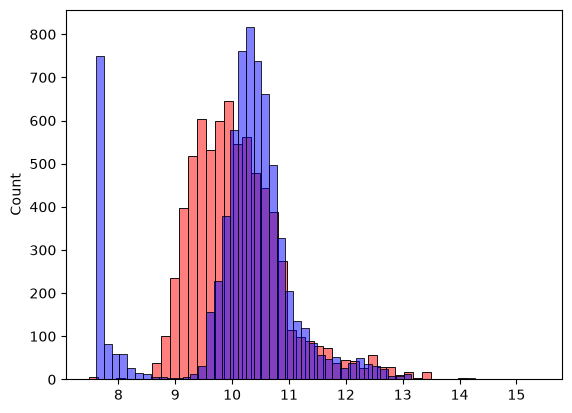

In [43]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

#### Define a function that will prepare the features matrix

In [44]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

#### Define the RMSE 

In [45]:
def rmse(y, y_pred):
    se = (y_pred - y)**2
    mse = se.mean()
    return np.sqrt(mse)

In [46]:
rmse_train = rmse(y_train, y_pred)

In [47]:
print(rmse_train)

0.7554591756909307


In [48]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

In [49]:
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

In [50]:
rmse_result = rmse(y_val, y_pred)

In [51]:
print(rmse_result)

0.7618297535729641


<span style="color: red;"> The model behaves on unseen data about as well as on the data it learned from</span>

### Feature engineering

In [52]:
def prepare_X(df):
    df=df.copy() #Important to keep the original data intact and work on a copy
    
    df['age'] = 2017 - df.year
    features = base + ['age']
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

#### let us check the improvement after adding the feature

In [53]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_val = w0 + X_val.dot(w)

rmse_fe = rmse(y_val, y_pred)
print(rmse_fe)

0.544678526677946


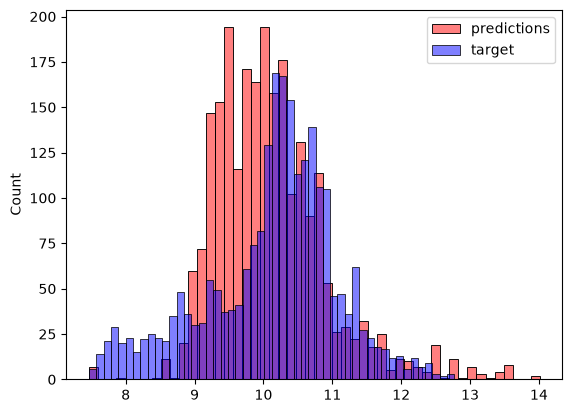

In [54]:
sns.histplot(y_pred, label= 'predictions', color= 'red', alpha= 0.5, bins= 50)
sns.histplot(y_val, label= 'target', color= 'blue', alpha= 0.5, bins= 50)
plt.legend()

## Categorical variables

#### Adding the number of doors feature

In [55]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()
    df['age'] = 2017 - df.year
    features.append('age')
    
# Adding the number of doors feature
    for v in [2, 3, 4]:
        df['num_doors_%s' %v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' %v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [56]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_val = w0 + X_val.dot(w)
rmse_cv = rmse(y_val, y_pred)

In [57]:
print(rmse_cv)

0.5481692303087367


In [58]:
df.make.value_counts().head()

make
chevrolet     1123
ford           881
volkswagen     809
toyota         746
dodge          626
Name: count, dtype: int64

In [59]:
makes = list(df.make.value_counts().head().index)
print(makes)

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']


#### Adding the make feature

In [60]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()
    df['age'] = 2017 - df.year
    features.append('age')
    
# Adding the number of doors feature
    for v in [2, 3, 4]:
        df['num_doors_%s' %v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' %v)
        
# Adding the make feature
    for v in makes:
        df['make_%s' %v] = (df.make == v).astype('int')
        features.append('make_%s' %v)
        
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [61]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_val = w0 + X_val.dot(w)
rmse_cv1 = rmse(y_val, y_pred)
print(rmse_cv1)

0.5580217328696961


#### For all categorical variables

In [62]:
# 1. Define the categories OUTSIDE the function using ONLY df_train
categorical_variables = [
    'make', 'model', 'engine_fuel_type', 'transmission_type', 
    'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style'
]

categories = {}
for c in categorical_variables:
    categories[c] = list(df_train[c].value_counts().head().index)

# 2. Define prepare_X so it strictly uses the pre-calculated categories
def prepare_X(df):
    df = df.copy()
    features = base.copy()
    
    df['age'] = 2017 - df.year
    features.append('age')
    
    # We loop over the global 'categories' dictionary we just made above
    for c, values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
            features.append('%s_%s' % (c, v))
            
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [63]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_val = w0 + X_val.dot(w)
rmse_all_cv = rmse(y_val, y_pred)
print(rmse_all_cv)

107.74747074260766


## Regularization

In [72]:
def train_linear_regression_reg(X, y, r=0.000000001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [73]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse_reg = rmse(y_val, y_pred)
print(rmse_reg)

107.7286127997367


## Tuning the model

In [66]:
for r in [0.00001, 0.0001, 0.001, 0.0, 0.1, 1, 10, 100, 1000]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    print(r, w0, score)

1e-05 8.022110098162615 107.7286075157782
0.0001 5.94405130944121 107.72860827207371
0.001 5.939521566076301 107.72860867170424
0.0 -5647989682712235.0 0.0
0.1 5.921257547969362 107.72865320010678
1 5.763918703335099 107.72897655836564
10 4.796472630737783 107.72809141988537
100 2.7563747772596585 107.6905858240138
1000 0.8131140806615332 107.57752090355838


#### There is a problem but suupose that the best parameter is 0.001

## Using the model

In [75]:
df_full_train = pd.concat([df_train, df_val])
print(df_full_train)

            make                    model  year  \
0      chevrolet                   cobalt  2008   
1         toyota                   matrix  2012   
2         subaru                  impreza  2016   
3     volkswagen                  vanagon  1991   
4           ford                    f-150  2017   
...          ...                      ...   ...   
2377         bmw                 7_series  2015   
2378       volvo                     xc90  2017   
2379       volvo                      v60  2015   
2380    maserati  granturismo_convertible  2015   
2381    cadillac          escalade_hybrid  2013   

                    engine_fuel_type  engine_hp  engine_cylinders  \
0                   regular_unleaded      148.0               4.0   
1                   regular_unleaded      132.0               4.0   
2                   regular_unleaded      148.0               4.0   
3                   regular_unleaded       90.0               4.0   
4           flex-fuel_(unleaded/e85)      

In [77]:
df_full_train = df_full_train.reset_index(drop=True)
print(df_full_train)

            make                    model  year  \
0      chevrolet                   cobalt  2008   
1         toyota                   matrix  2012   
2         subaru                  impreza  2016   
3     volkswagen                  vanagon  1991   
4           ford                    f-150  2017   
...          ...                      ...   ...   
9525         bmw                 7_series  2015   
9526       volvo                     xc90  2017   
9527       volvo                      v60  2015   
9528    maserati  granturismo_convertible  2015   
9529    cadillac          escalade_hybrid  2013   

                    engine_fuel_type  engine_hp  engine_cylinders  \
0                   regular_unleaded      148.0               4.0   
1                   regular_unleaded      132.0               4.0   
2                   regular_unleaded      148.0               4.0   
3                   regular_unleaded       90.0               4.0   
4           flex-fuel_(unleaded/e85)      

In [78]:
X_full_train = prepare_X(df_full_train)

In [79]:
y_full_train = np.concatenate([y_train, y_val])

In [80]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [81]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(26.853398256778927)

### Predicting the price of a car

In [83]:
car = df_test.iloc[20].to_dict()
car

{'make': 'gmc',
 'model': 'sierra_1500',
 'year': 2016,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 355.0,
 'engine_cylinders': 8.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'four_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'large',
 'vehicle_style': 'crew_cab_pickup',
 'highway_mpg': 22,
 'city_mpg': 16,
 'popularity': 549}

In [84]:
df_small = pd.DataFrame([car])
X_small = prepare_X(df_small)

In [85]:
y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]
y_pred

np.float64(-3.5194147610890614)

In [88]:
np.expm1(y_pred)

np.float64(-0.9703832370209459)

In [89]:
np.expm1(y_test[20])

np.float64(54240.00000000002)